# CS 4379G Assignment_01
In this assignment I am investigating the correlation between the amount of titles added to Netflix per year and the countries with the most titles added to Netflix overall.
---

## 0) Recommended folder structure
```
assignment_01/
  notebooks/
    analysis.ipynb
  data/
    netflix_titles.csv

```
> Put the CSV in `data/netflix/` before running the load cell.

## 1) Imports and Settings

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')

### Data loading and a brief data dictionary (what each key column means).

In [35]:
DATA_DIR = Path("../data/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / "netflix_titles.csv"

if csv_path.exists():
    print("✅ Found:", csv_path)
else:
    print("netflix_titles.csv not found. Please ensure netflix_titles.csv is located within data/")

# load data
df = pd.read_csv(csv_path)

✅ Found: ..\data\netflix_titles.csv


In [36]:
# data dictionary of each key column
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## 2) Data cleaning
- Check for missing values
- Drop duplicate entries
- Parse `date_added`and create `year_added`

In [38]:
# check for missing values
df.isna().sum().sort_values(ascending=False).head(12)


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [39]:
# drop duplicates
df.drop_duplicates()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [40]:
# Parse dates (coerce errors -> NaT)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

In [41]:
# count_by helper function
def count_by(column_name: str, drop: bool):
    column_counts = df[column_name].value_counts(dropna=drop)
    return column_counts

## 2) Analysis
---

In [ ]:
# Grouped Summary: Title Count by Type
type_counts = count_by("type", False)
print(type_counts)


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
# Grouper Summary: Title Count by Country (Not including NaN)
country_counts = count_by("country", True)
print(country_counts.head(10))

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [ ]:
# Trend over Time: Titles Added per Year (ignoring missing dates)
added_per_year = df.dropna(subset=["year_added"]).groupby("year_added").size()
print(added_per_year)


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64


# 3) Visualization
---

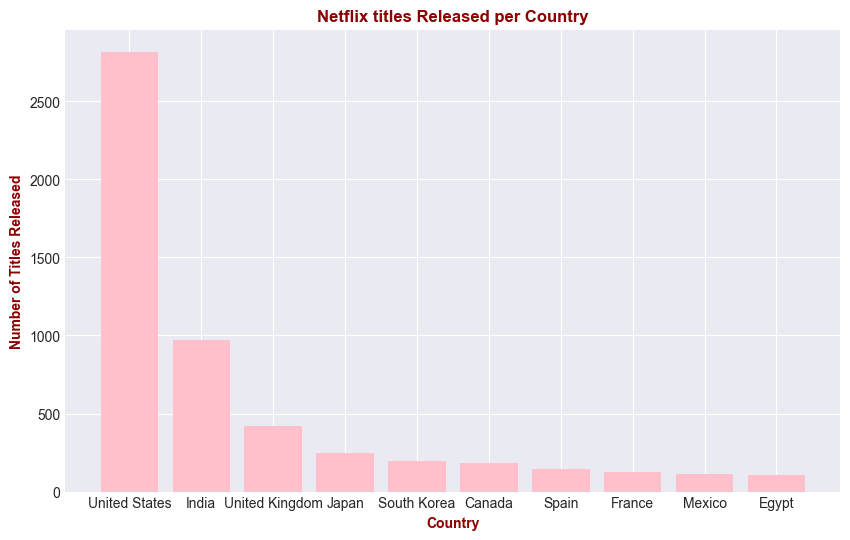

In [46]:
# Q1: Which countries (or genres/listed_in categories) contribute the most titles, and how has that changed over time? 
plt.figure(figsize=(10, 6))
plt.bar(country_counts.head(10).index.astype(str), country_counts.head(10).values, color = 'pink')

plt.xlabel("Country", fontweight='bold', color='darkred')
plt.ylabel("Number of Titles Released", fontweight='bold', color='darkred')
plt.title("Netflix titles Released per Country", fontweight='bold', color='darkred')
plt.show()

This chart shows that the United States leads the number of titles released per country by a significant margin. Seeing as 2000 titles were added to Netflix in 2018-2019 (see below), and no country other than the United States has added over 2000 titles to Netflix in its entirety, it is likely that this spike is mainly made up of United States titles. This means that the United States has increased its addition of titles to Netflix as time has gone on.

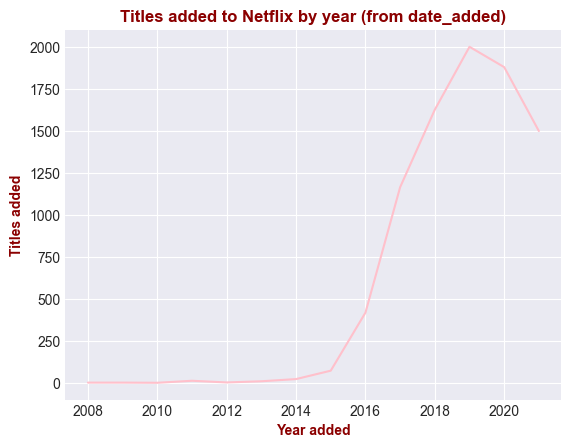

In [47]:
# Q2: How has the number of titles added to Netflix changed over time (by year)?
plt.figure()
plt.plot(added_per_year.index, added_per_year.values, color='pink')
plt.xlabel("Year added", fontweight='bold', color='darkred')
plt.ylabel("Titles added", fontweight='bold', color='darkred')
plt.title("Titles added to Netflix by year (from date_added)", fontweight='bold', color='darkred')
plt.show()

This line chart shows a spike in Titles added to Netflix in 2018-2019. This peak may suggest a year of higher streaming rates, higher profit from increased subscriber counts, or a higher demand for titles that resulted in Netflix acquiring more.